# 深度学习实训项目 - 神经网络后向传播的实现

**课程**: 深度学习基础与应用  
**学校**: 广东工商职业技术大学  
**学期**: 2025-2026学年第2学期  

---

## 写给新手的话

本Notebook为新手小白准备，每行代码都有详细中文解释。
专业单词会标注音标，帮助你学习。
建议逐行阅读，理解每行代码的作用。

## 第一步：环境准备 - 导入必要的库

**import**（音：因剖特）- 导入，意思是把别人写好的工具箱拿过来用
**library**（音：来布瑞瑞）- 库，就是工具箱，里面有很多现成的功能

In [1]:
# import（音：因剖特）导入 - 把别人写好的代码工具箱拿过来用
# os（音：欧艾斯）- operating system（音：奥普瑞挺 西斯特姆）操作系统模块，用来操作电脑文件
import os

# numpy（音：南派）- 数字计算库，专门处理数字矩阵运算，是Python最常用的数学工具
# np是numpy的简称，后面代码都用np代替numpy，写起来更短
import numpy as np

# matplotlib（音：麦特普洛特利布）- 画图库，用来画图表、曲线图
# pyplot（音：派普洛特）- matplotlib里面的画图工具模块
# plt是pyplot的简称
import matplotlib.pyplot as plt

# tensorflow（音：腾索弗洛）- 谷歌开发的深度学习框架，专门用来搭建神经网络
# tf是tensorflow的简称
import tensorflow as tf

# keras（音：凯拉斯）- 高级神经网络API，是tensorflow的一部分，让搭建神经网络更简单
from tensorflow import keras

# layers（音：莱尔斯）- 层，神经网络的每一层
# models（音：莫豆丝）- 模型，整个神经网络
from tensorflow.keras import layers, models

# mnist（音：艾姆尼斯特）- 手写数字数据集，包含0-9的手写数字图片
from tensorflow.keras.datasets import mnist

# to_categorical（音：吐 凯提够瑞口）- 转换为分类格式，把数字标签变成one-hot编码
from tensorflow.keras.utils import to_categorical

# 设置中文字体显示，让图表可以显示中文
# rcParams（音：阿尔西 帕拉米特斯）- 运行配置参数
# font（音：方特）- 字体
# sans-serif（音：桑斯 塞瑞夫）- 无衬线字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']

# axes（音：艾克西兹）- 坐标轴
# unicode_minus（音：尤尼扣德 麦诺斯）- 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False

# 打印TensorFlow的版本号，确认安装成功
# version（音：沃辰）- 版本
print(f"TensorFlow版本: {tf.__version__}")

# 打印NumPy的版本号
print(f"NumPy版本: {np.__version__}")

TensorFlow版本: 2.21.0
NumPy版本: 2.4.4


---

# 任务一：使用Keras高层API搭建神经网络实现手写数字分类

**API**（音：艾皮艾）- Application Programming Interface（音：艾普里克逊 普罗格瑞明 因特飞斯），应用程序接口，就是别人写好的一套规则，你按照规则调用就行

## 1.1 加载并预处理MNIST数据集

**dataset**（音：戴塔塞特）- 数据集，就是一堆数据的集合
**preprocess**（音：普瑞普劳塞斯）- 预处理，在正式处理之前先做一些准备工作

In [2]:
# def（音：戴夫）- define（音：迪凡）定义，用来定义一个函数
# function（音：方克逊）- 函数，一段可以重复使用的代码
# load_and_preprocess_data（音：楼的 安的 普瑞普劳塞斯 戴塔）- 加载和预处理数据
def load_and_preprocess_data():
    """
    文档字符串：说明这个函数的作用
    加载MNIST数据集并进行预处理
    
    Returns（音：瑞腾兹）- 返回值，函数执行完后返回的结果
    tuple（音：塔普尔）- 元组，一种数据结构，可以装多个值
    """
    
    # 加载MNIST数据集
    # load_data（音：楼的 戴塔）- 加载数据
    # mnist.load_data()会自动从网上下载MNIST数据集（如果本地没有的话）
    # 返回两个元组：(训练图片, 训练标签), (测试图片, 测试标签)
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    
    # 归一化（Normalization，音：诺默来贼逊）
    # 将像素值从 [0, 255] 缩放到 [0, 1]
    # 为什么要归一化？因为神经网络喜欢小数字，训练效果更好
    # astype（音：艾斯泰普）- 转换数据类型
    # float32（音：弗洛特 瑟提吐）- 32位浮点数，带小数点的数字
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    
    # 将图像从 28x28 展平为 784 维向量
    # reshape（音：瑞谢普）- 重塑形状，改变数据的维度
    # shape（音：谢普）- 形状，数据的维度
    # 28x28 = 784，把二维图片变成一维向量
    x_train = x_train.reshape((x_train.shape[0], 28 * 28))
    x_test = x_test.reshape((x_test.shape[0], 28 * 28))
    
    # 将标签转换为one-hot编码
    # one-hot（音：万 浩特）- 一种编码方式，把数字变成向量
    # 例如：数字3 -> [0,0,0,1,0,0,0,0,0,0]
    # 例如：数字7 -> [0,0,0,0,0,0,0,1,0,0]
    # 10表示有10个类别（数字0-9）
    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)
    
    # 打印数据集的形状信息
    # f-string（音：艾夫 斯特瑞因）- 格式化字符串，可以在字符串中插入变量
    print(f"训练集形状: {x_train.shape}, 标签形状: {y_train.shape}")
    print(f"测试集形状: {x_test.shape}, 标签形状: {y_test.shape}")
    
    # return（音：瑞腾）- 返回，把结果传回给调用者
    return x_train, y_train, x_test, y_test

# 调用上面定义的函数，加载数据
# x_train - 训练图片数据
# y_train - 训练标签数据
# x_test - 测试图片数据
# y_test - 测试标签数据
x_train, y_train, x_test, y_test = load_and_preprocess_data()

训练集形状: (60000, 784), 标签形状: (60000, 10)
测试集形状: (10000, 784), 标签形状: (10000, 10)


## 1.2 可视化样本数据

**visualize**（音：维秀艾斯）- 可视化，把数据用图形展示出来
**sample**（音：桑普尔）- 样本，从数据集中取出的一个例子

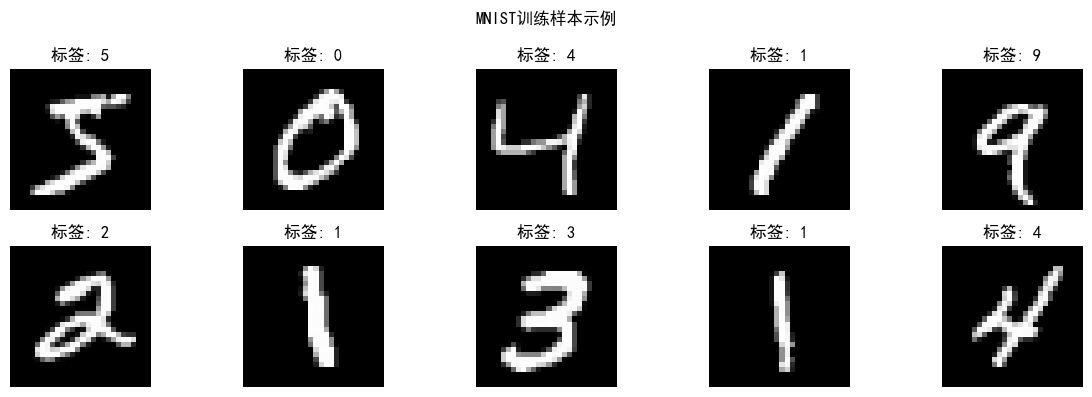

In [3]:
# 可视化部分训练样本
# figure（音：菲格尔）- 图形，创建一个新的画图窗口
# figsize（音：菲格 赛斯）- 图形大小，单位是英寸
plt.figure(figsize=(12, 4))

# for（音：佛）- 循环语句，重复执行一段代码
# range(10) - 生成0到9的数字序列
# i - 循环变量，每次循环取一个值
for i in range(10):
    
    # subplot（音：萨普洛特）- 子图，在一个大图中画多个小图
    # 2, 5表示2行5列的布局
    # i + 1表示第几个子图（从1开始计数）
    plt.subplot(2, 5, i + 1)
    
    # imshow（音：艾姆 秀）- image show，显示图片
    # x_train[i] - 第i张训练图片
    # reshape(28, 28) - 把784维向量变回28x28的二维图片
    # cmap='gray'（音：西艾姆普 格雷）- 颜色映射为灰度，黑白图片
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    
    # title（音：泰特尔）- 标题
    # np.argmax（音：南派 阿尔格马克斯）- 取最大值的位置
    # y_train[i]是one-hot编码，argmax找出哪个位置是1，就是哪个数字
    plt.title(f'标签: {np.argmax(y_train[i])}')
    
    # axis（音：艾克西丝）- 坐标轴
    # off（音：奥夫）- 关闭，不显示坐标轴
    plt.axis('off')

# suptitle（音：苏普泰特尔）- 超级标题，整个图的大标题
plt.suptitle('MNIST训练样本示例')

# tight_layout（音：泰特 莱奥特）- 紧凑布局，自动调整子图间距
plt.tight_layout()

# show（音：秀）- 显示图形
plt.show()

## 1.3 构建神经网络模型

**neural network**（音：纽若 奈特沃克）- 神经网络，模仿人脑神经元连接的计算模型
**model**（音：莫豆）- 模型，这里指神经网络模型
**build**（音：比欧德）- 构建、搭建

In [4]:
# 定义构建模型的函数
# build_model（音：比欧德 莫豆）- 构建模型
def build_model():
    """
    使用Keras Sequential API构建神经网络模型
    
    Sequential（音：西奎恩朔）- 顺序的，一层一层按顺序连接
    
    模型结构说明：
    - 输入层（Input Layer，音：因普特 莱尔）：784个神经元
      对应28x28=784像素的图片展平后的向量
    
    - 隐藏层1（Hidden Layer 1，音：黑灯 莱尔）：256个神经元
      activation='relu'（音：艾克提维逊 瑞路）
      ReLU - Rectified Linear Unit（音：瑞克提凡德 利尼尔 尤尼特）
      整流线性单元，一种激活函数：负数变0，正数不变
    
    - Dropout层（音：卓普奥特）：随机丢弃20%的神经元
      防止过拟合（Overfitting，音：欧沃菲挺）
      过拟合 = 模型死记硬背训练数据，对新数据表现差
    
    - 隐藏层2（Hidden Layer 2）：128个神经元
    
    - 输出层（Output Layer，音：奥特普特 莱尔）：10个神经元
      activation='softmax'（音：索夫特麦克斯）
      Softmax把输出变成概率分布，所有概率之和为1
      对应10个数字类别（0-9）
    """
    
    # 创建Sequential模型
    # 用列表传入每一层，按顺序堆叠
    model = models.Sequential([
        
        # 输入层
        # Input（音：因普特）- 输入
        # shape=(784,) - 输入数据的形状是784维向量
        layers.Input(shape=(784,)),
        
        # 第一隐藏层
        # Dense（音：登斯）- 全连接层，每个神经元与上一层所有神经元相连
        # 256 - 这一层有256个神经元
        layers.Dense(256, activation='relu'),
        
        # Dropout正则化层
        # 0.2表示训练时随机丢弃20%的神经元
        # 这样模型不会过度依赖某些神经元，提高泛化能力
        # generalization（音：真瑞来贼逊）- 泛化，模型对新数据的表现能力
        layers.Dropout(0.2),
        
        # 第二隐藏层
        # 128个神经元
        layers.Dense(128, activation='relu'),
        
        # 又一个Dropout层
        layers.Dropout(0.2),
        
        # 输出层
        # 10个神经元，对应0-9这10个数字
        # softmax激活函数输出概率分布
        layers.Dense(10, activation='softmax')
    ])
    
    # compile（音：康派欧）- 编译，配置模型的训练方式
    model.compile(
        
        # optimizer（音：奥普提迈泽）- 优化器，用来更新权重的方法
        # adam（音：艾达姆）- 一种自适应学习率的优化算法
        # 自动调整学习步长，收敛快效果好
        optimizer='adam',
        
        # loss（音：劳斯）- 损失函数，衡量预测结果与真实答案的差距
        # categorical_crossentropy（音：凯提够瑞口 克劳斯安戳皮）
        # 分类交叉熵，专门用于多分类任务的损失函数
        loss='categorical_crossentropy',
        
        # metrics（音：麦垂克斯）- 评估指标，训练时监控的指标
        # accuracy（音：艾克尤瑞西）- 准确率，预测正确的比例
        metrics=['accuracy']
    )
    
    # 打印模型结构信息
    # summary（音：萨莫瑞）- 摘要、总结
    print("模型结构：")
    model.summary()
    
    # 返回编译好的模型
    return model

# 调用函数构建模型
model = build_model()

模型结构：


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 1.4 前向传播与反向传播演示

**forward propagation**（音：佛沃德 普罗普给逊）- 前向传播，数据从输入层流向输出层
**backward propagation**（音：拜克沃德 普罗普给逊）- 反向传播，误差从输出层传回输入层，计算梯度
**gradient**（音：格雷迪恩特）- 梯度，损失函数对参数的导数，指示参数更新的方向

In [5]:
# 定义演示前向传播和反向传播的函数
# demonstrate（音：戴蒙斯特瑞特）- 演示、展示
# forward（音：佛沃德）- 向前的
# backward（音：拜克沃德）- 向后的
# propagation（音：普罗普给逊）- 传播
def demonstrate_forward_backward_propagation(model, x_train, y_train):
    """
    演示前向传播和反向传播过程
    """
    
    # "="*60 表示把"="重复60次，画一条分隔线
    print("\n" + "="*60)
    print("前向传播与反向传播演示")
    print("="*60)
    
    # 取一个样本进行演示
    # sample_idx（音：桑普尔 因代克斯）- 样本索引
    # idx是index（音：因代克斯）的缩写，索引就是编号
    sample_idx = 0
    
    # 取出第0个样本
    # [sample_idx:sample_idx+1] - 切片操作，取一个样本（保持二维形状）
    x_sample = x_train[sample_idx:sample_idx+1]
    y_sample = y_train[sample_idx:sample_idx+1]
    
    # 打印样本信息
    print(f"\n选取样本索引: {sample_idx}")
    
    # shape（音：谢普）- 形状
    print(f"输入形状: {x_sample.shape}")
    print(f"标签形状: {y_sample.shape}")
    
    # argmax取最大值的位置，就是one-hot编码中1的位置
    print(f"真实标签: {np.argmax(y_sample)}")
    
    # ========== 前向传播部分 ==========
    print("\n--- 前向传播过程 ---")
    
    # predict（音：普瑞迪克特）- 预测
    # verbose=0（音：沃博斯 泽罗）- 不显示进度信息
    # 先进行一次预测，建立模型内部连接
    _ = model.predict(x_sample, verbose=0)
    
    # 创建逐层输出模型，用来观察每一层的输出
    # 从tensorflow.keras.layers导入Input
    from tensorflow.keras.layers import Input
    
    # 定义输入层
    input_layer = Input(shape=(784,))
    
    # layer_outputs（音：莱尔 奥特普茨）- 层输出列表
    layer_outputs = []
    
    # x是中间变量，存储每层的输出
    x = input_layer
    
    # 遍历模型的每一层
    # zip（音：兹普）- 把两个列表打包在一起，同时遍历
    for layer in model.layers:
        # 把当前层的输出作为下一层的输入
        x = layer(x)
        # 把当前层的输出添加到列表中
        layer_outputs.append(x)
    
    # 创建一个新模型，输入是原始输入，输出是每一层的输出
    activation_model = models.Model(inputs=input_layer, outputs=layer_outputs)
    
    # 用新模型预测，得到每一层的输出
    activations = activation_model.predict(x_sample, verbose=0)
    
    # 遍历每一层和对应的输出
    # enumerate（音：伊纽梅瑞特）- 枚举，同时获取索引和值
    for i, (layer, activation) in enumerate(zip(model.layers, activations)):
        # 打印层的信息
        # name（音：内姆）- 名称
        print(f"层 {i+1} ({layer.name}): 输出形状 = {activation.shape}")
        
        # 如果是最后一层（输出层）
        # len（音：冷）- length（音：冷斯），长度
        if i == len(model.layers) - 1:
            # round（音：朗德）- 四舍五入
            print(f"  输出概率分布: {activation[0].round(4)}")
            print(f"  预测类别: {np.argmax(activation[0])}")
    
    # ========== 反向传播部分 ==========
    print("\n--- 反向传播过程（梯度计算）---")
    
    # 把numpy数组转换为tensorflow张量（tensor，音：腾索）
    # tensor（音：腾索）- 张量，TensorFlow中的基本数据类型
    # convert_to_tensor（音：康沃特 吐 腾索）- 转换为张量
    # dtype（音：迪泰普）- data type（音：戴塔 泰普），数据类型
    x_tensor = tf.convert_to_tensor(x_sample, dtype=tf.float32)
    y_tensor = tf.convert_to_tensor(y_sample, dtype=tf.float32)
    
    # GradientTape（音：格雷迪恩特 泰普）- 梯度磁带
    # 用来记录计算过程，以便后续自动计算梯度
    # with语句创建一个上下文环境
    with tf.GradientTape() as tape:
        
        # watch（音：沃奇）- 监视，让tape跟踪这个张量的变化
        tape.watch(x_tensor)
        
        # 前向传播：得到预测结果
        predictions = model(x_tensor)
        
        # 计算损失
        # categorical_crossentropy（音：凯提够瑞口 克劳斯安戳皮）
        loss = tf.keras.losses.categorical_crossentropy(y_tensor, predictions)
    
    # 计算梯度
    # gradient（音：格雷迪恩特）- 梯度
    # trainable_variables（音：吹纳波 维瑞艾布尔斯）- 可训练变量（权重和偏置）
    gradients = tape.gradient(loss, model.trainable_variables)
    
    # 打印损失值
    # numpy()把tensorflow张量转换为numpy数组
    print(f"损失值: {loss.numpy()[0]:.6f}")
    
    # 打印各层参数的梯度统计信息
    print("\n各层参数梯度统计:")
    
    # 遍历梯度和对应的变量
    # var（音：维艾）- variable（音：维瑞艾波），变量
    for i, (grad, var) in enumerate(zip(gradients, model.trainable_variables)):
        
        # 如果梯度不为空
        if grad is not None:
            print(f"  参数 {i+1} ({var.name}):")
            print(f"    形状: {grad.shape}")
            
            # reduce_mean（音：瑞丢斯 米恩）- 求平均值
            # abs（音：艾布斯）- absolute（音：艾布斯路特），绝对值
            print(f"    梯度均值: {tf.reduce_mean(tf.abs(grad)).numpy():.6f}")
            
            # reduce_max（音：瑞丢斯 麦克斯）- 求最大值
            print(f"    梯度最大值: {tf.reduce_max(tf.abs(grad)).numpy():.6f}")
    
    # 打印结束分隔线
    print("\n" + "="*60)

# 调用函数运行演示
demonstrate_forward_backward_propagation(model, x_train, y_train)


前向传播与反向传播演示

选取样本索引: 0
输入形状: (1, 784)
标签形状: (1, 10)
真实标签: 5

--- 前向传播过程 ---
层 1 (dense): 输出形状 = (1, 256)
层 2 (dropout): 输出形状 = (1, 256)
层 3 (dense_1): 输出形状 = (1, 128)
层 4 (dropout_1): 输出形状 = (1, 128)
层 5 (dense_2): 输出形状 = (1, 10)
  输出概率分布: [0.1536 0.0892 0.1063 0.0969 0.096  0.1021 0.0771 0.0887 0.137  0.0529]
  预测类别: 0

--- 反向传播过程（梯度计算）---
损失值: 2.281493

各层参数梯度统计:
  参数 1 (kernel):
    形状: (784, 256)
    梯度均值: 0.003590
    梯度最大值: 0.175474
  参数 2 (bias):
    形状: (256,)
    梯度均值: 0.026077
    梯度最大值: 0.175474
  参数 3 (kernel):
    形状: (256, 128)
    梯度均值: 0.010678
    梯度最大值: 0.255136
  参数 4 (bias):
    形状: (128,)
    梯度均值: 0.059771
    梯度最大值: 0.232568
  参数 5 (kernel):
    形状: (128, 10)
    梯度均值: 0.028024
    梯度最大值: 0.734325
  参数 6 (bias):
    形状: (10,)
    梯度均值: 0.179574
    梯度最大值: 0.897868



## 1.5 训练模型

**train**（音：吹恩）- 训练，让模型学习数据中的规律
**fit**（音：菲特）- 拟合，让模型适应数据
**epoch**（音：艾poch）- 轮次，把所有训练数据过一遍叫一轮

In [6]:
# 开始训练模型
# \n是换行符
print("\n开始训练模型...")

# fit（音：菲特）- 训练、拟合
# history（音：希斯特瑞）- 历史，记录训练过程中的数据
history = model.fit(
    
    # 训练数据：输入图片和标签
    x_train, y_train,
    
    # batch_size（音：拜奇 赛斯）- 批次大小
    # 每次取128张图片一起计算梯度，更新一次权重
    # 不用一次处理所有数据，节省内存
    batch_size=128,
    
    # epochs（音：艾波克斯）- 训练轮数
    # 把整个训练数据集过10遍
    epochs=10,
    
    # validation_split（音：瓦利戴逊 斯普利特）- 验证集划分比例
    # 从训练数据中拿出10%作为验证集，用来监控模型表现
    # 验证集不参与训练，用来判断模型是否过拟合
    validation_split=0.1,
    
    # verbose（音：沃博斯）- 详细程度
    # 1表示显示进度条
    verbose=1
)


开始训练模型...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8936 - loss: 0.3600 - val_accuracy: 0.9653 - val_loss: 0.1229
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9548 - loss: 0.1488 - val_accuracy: 0.9713 - val_loss: 0.0924
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9674 - loss: 0.1065 - val_accuracy: 0.9755 - val_loss: 0.0758
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9739 - loss: 0.0836 - val_accuracy: 0.9763 - val_loss: 0.0753
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9785 - loss: 0.0691 - val_accuracy: 0.9788 - val_loss: 0.0657
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9813 - loss: 0.0599 - val_accuracy: 0.9793 - val_loss: 0.0716
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9822 - loss: 0.0535 - val_accuracy: 0.9798 - val_loss: 0.0629
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9844 - loss: 0.0466 - val_a

## 1.6 评估模型

**evaluate**（音：伊瓦柳艾特）- 评估，测试模型的性能
**test**（音：泰斯特）- 测试
**accuracy**（音：艾克尤瑞西）- 准确率

In [7]:
# 评估模型在测试集上的表现
print("\n评估模型性能...")

# evaluate（音：伊瓦柳艾特）- 评估
# 返回两个值：损失值和准确率
# verbose=0表示不显示进度
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

# :.4f表示保留4位小数
print(f"测试集损失: {test_loss:.4f}")
print(f"测试集准确率: {test_accuracy:.4f}")


评估模型性能...
测试集损失: 0.0622
测试集准确率: 0.9811


## 1.7 保存和加载模型

**save**（音：塞夫）- 保存
**load**（音：楼的）- 加载

In [8]:
# 保存训练好的模型到文件
# .keras是Keras模型文件格式
model.save('mnist_model.keras')
print("模型已保存到: mnist_model.keras")

# 从文件加载模型
# load_model（音：楼的 莫豆）- 加载模型
loaded_model = keras.models.load_model('mnist_model.keras')
print("模型已加载")

# 验证加载的模型是否能正常使用
# 用加载的模型评估测试集
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)

# 打印加载模型的准确率
print(f"加载模型测试准确率: {loaded_acc:.4f}")

模型已保存到: mnist_model.keras
模型已加载
加载模型测试准确率: 0.9811


## 1.8 可视化训练历史

**history**（音：希斯特瑞）- 历史，记录训练过程中的损失和准确率变化

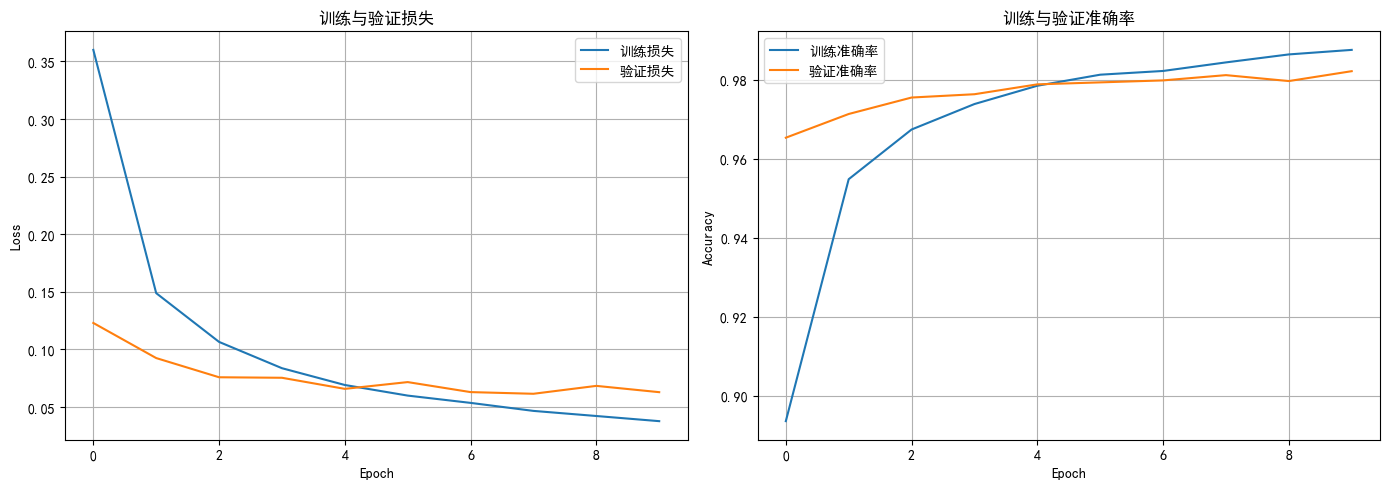

训练历史曲线已保存


In [9]:
# 绘制训练历史曲线

# subplots（音：萨普洛茨）- 创建多个子图
# 1, 2表示1行2列，创建两个并排的小图
# fig是整个图，axes是两个子图组成的数组
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ========== 左图：损失曲线 ==========

# plot（音：普洛特）- 绘制曲线
# history.history['loss'] - 训练过程中的损失值列表
# label（音：莱波）- 图例标签
axes[0].plot(history.history['loss'], label='训练损失')

# val_loss（音：瓦尔 劳斯）- validation loss，验证集损失
axes[0].plot(history.history['val_loss'], label='验证损失')

# set_xlabel（音：塞特 艾克斯 莱波）- 设置x轴标签
axes[0].set_xlabel('Epoch')

# set_ylabel（音：塞特 歪 莱波）- 设置y轴标签
axes[0].set_ylabel('Loss')

# set_title（音：塞特 泰特尔）- 设置标题
axes[0].set_title('训练与验证损失')

# legend（音：莱真德）- 显示图例
axes[0].legend()

# grid（音：格瑞德）- 显示网格线
axes[0].grid(True)

# ========== 右图：准确率曲线 ==========

# accuracy（音：艾克尤瑞西）- 准确率
axes[1].plot(history.history['accuracy'], label='训练准确率')

# val_accuracy（音：瓦尔 艾克尤瑞西）- 验证集准确率
axes[1].plot(history.history['val_accuracy'], label='验证准确率')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('训练与验证准确率')
axes[1].legend()
axes[1].grid(True)

# 自动调整子图布局
plt.tight_layout()

# savefig（音：塞夫 菲格）- 保存图片
# dpi=150（音：迪皮艾 万菲提）- 分辨率，每英寸150个点
# bbox_inches='tight'（音：比比 因奇兹 泰特）- 紧凑边界框
plt.savefig('task1_training_history.png', dpi=150, bbox_inches='tight')

# 显示图形
plt.show()

print("训练历史曲线已保存")

## 1.9 可视化预测结果

**prediction**（音：普瑞迪克逊）- 预测，模型对输入数据的输出
**result**（音：瑞佐尔特）- 结果

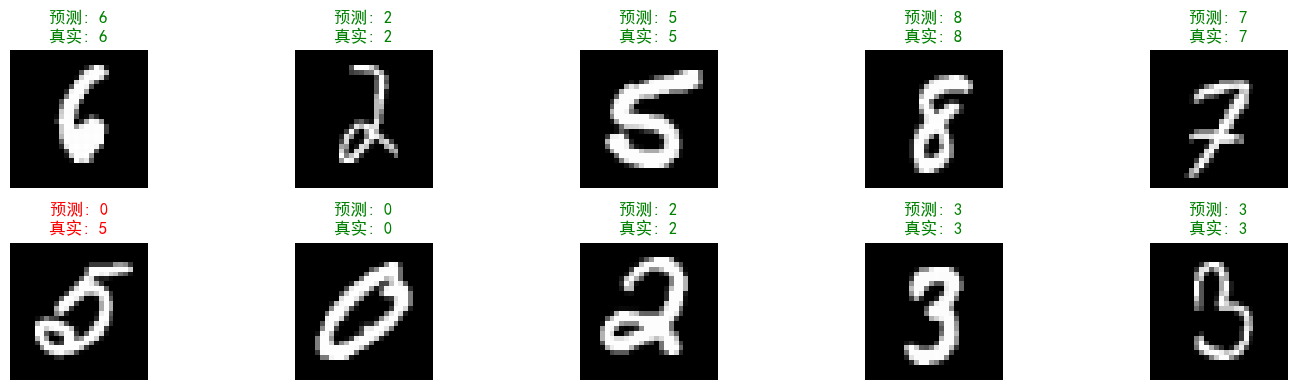

预测可视化已保存


In [10]:
# 可视化预测结果

# 设置要展示的样本数量
num_samples = 10

# random（音：兰登）- 随机
# choice（音：超艾斯）- 选择
# 从测试集中随机选10个样本
# len(x_test) - 测试集的总数量
# replace=False（音：瑞普莱斯 佛尔斯）- 不重复选择
indices = np.random.choice(len(x_test), num_samples, replace=False)

# 创建画图窗口
plt.figure(figsize=(15, 4))

# 遍历选中的样本
for i, idx in enumerate(indices):
    
    # 取出第idx个样本
    sample = x_test[idx:idx+1]
    
    # 用模型预测
    prediction = model.predict(sample, verbose=0)
    
    # 取概率最大的类别作为预测结果
    predicted_label = np.argmax(prediction)
    
    # 真实标签
    true_label = np.argmax(y_test[idx])
    
    # 创建子图
    plt.subplot(2, 5, i + 1)
    
    # 显示图片
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    
    # 根据预测是否正确设置标题颜色
    # 预测正确用绿色，错误用红色
    # if（音：伊夫）- 如果
    # else（音：艾欧斯）- 否则
    # == 表示判断是否相等
    color = 'green' if predicted_label == true_label else 'red'
    
    # 设置标题，显示预测和真实标签
    # \n是换行符
    plt.title(f'预测: {predicted_label}\n真实: {true_label}', color=color)
    
    # 不显示坐标轴
    plt.axis('off')

# 调整布局
plt.tight_layout()

# 保存图片
plt.savefig('task1_predictions.png', dpi=150, bbox_inches='tight')

# 显示图形
plt.show()

print("预测可视化已保存")

---

# 任务二：对比交叉熵与均方误差损失对手写数字分类的影响

**compare**（音：康佩尔）- 对比、比较
**cross entropy**（音：克劳斯 安戳皮）- 交叉熵
**mean squared error**（音：米恩 斯夸尔德 艾若）- 均方误差
**loss function**（音：劳斯 方克逊）- 损失函数

## 2.1 损失函数特性分析

**categorical crossentropy**（音：凯提够瑞口 克劳斯安戳皮）- 分类交叉熵
**mean squared error**（音：米恩 斯夸尔德 艾若）- 均方误差

In [11]:
# 打印损失函数的理论说明
# 使用三引号字符串可以跨多行
print("""
【交叉熵损失 (Categorical Crossentropy)】
1. 数学公式: L = -Σ(y_true * log(y_pred))
   L - 损失值
   Σ（音：西格玛）- 求和符号
   y_true（音：歪 处）- 真实标签
   y_pred（音：歪 普瑞德）- 预测值
   log（音：劳格）- 对数函数

2. 特点:
   - 专门针对分类任务设计
   - 对预测概率与真实标签的差异敏感
   - 梯度在误差大时较大，收敛速度快
   - 与Softmax激活函数配合效果最佳

3. 适用场景: 多分类任务的首选损失函数

【均方误差损失 (Mean Squared Error)】
1. 数学公式: L = (1/n) * Σ(y_true - y_pred)²
   n - 样本数量
   ² - 平方

2. 特点:
   - 通用损失函数，originally用于回归任务
   - 梯度随误差线性变化
   - 在分类任务中可能导致梯度消失问题
   - 对离群值敏感

3. 适用场景: 回归任务，不推荐用于分类任务

【关键差异】
1. 梯度特性:
   - 交叉熵: 梯度与误差成正比，学习信号强
   - MSE: 梯度受Softmax导数影响，可能过小

2. 收敛速度:
   - 交叉熵: 收敛更快，通常需要更少epoch
   - MSE: 收敛较慢，可能需要更多epoch

3. 最终性能:
   - 交叉熵: 在分类任务上通常达到更高准确率
   - MSE: 在分类任务上性能通常较差
""")


【交叉熵损失 (Categorical Crossentropy)】
1. 数学公式: L = -Σ(y_true * log(y_pred))
   L - 损失值
   Σ（音：西格玛）- 求和符号
   y_true（音：歪 处）- 真实标签
   y_pred（音：歪 普瑞德）- 预测值
   log（音：劳格）- 对数函数

2. 特点:
   - 专门针对分类任务设计
   - 对预测概率与真实标签的差异敏感
   - 梯度在误差大时较大，收敛速度快
   - 与Softmax激活函数配合效果最佳

3. 适用场景: 多分类任务的首选损失函数

【均方误差损失 (Mean Squared Error)】
1. 数学公式: L = (1/n) * Σ(y_true - y_pred)²
   n - 样本数量
   ² - 平方

2. 特点:
   - 通用损失函数，originally用于回归任务
   - 梯度随误差线性变化
   - 在分类任务中可能导致梯度消失问题
   - 对离群值敏感

3. 适用场景: 回归任务，不推荐用于分类任务

【关键差异】
1. 梯度特性:
   - 交叉熵: 梯度与误差成正比，学习信号强
   - MSE: 梯度受Softmax导数影响，可能过小

2. 收敛速度:
   - 交叉熵: 收敛更快，通常需要更少epoch
   - MSE: 收敛较慢，可能需要更多epoch

3. 最终性能:
   - 交叉熵: 在分类任务上通常达到更高准确率
   - MSE: 在分类任务上性能通常较差



## 2.2 使用交叉熵损失训练模型

**categorical crossentropy**（音：凯提够瑞口 克劳斯安戳皮）- 分类交叉熵

In [12]:
# 构建使用交叉熵损失的模型
# model_ce - model with Cross Entropy（音：克劳斯 安戳皮）
model_ce = models.Sequential([
    
    # 输入层
    layers.Input(shape=(784,)),
    
    # 第一隐藏层：256个神经元，ReLU激活
    layers.Dense(256, activation='relu'),
    
    # Dropout防止过拟合
    layers.Dropout(0.2),
    
    # 第二隐藏层：128个神经元
    layers.Dense(128, activation='relu'),
    
    # Dropout
    layers.Dropout(0.2),
    
    # 输出层：10个神经元，Softmax激活
    layers.Dense(10, activation='softmax')
])

# 编译模型
model_ce.compile(
    
    # 优化器
    optimizer='adam',
    
    # 损失函数：分类交叉熵
    # categorical_crossentropy（音：凯提够瑞口 克劳斯安戳皮）
    loss='categorical_crossentropy',
    
    # 评估指标：准确率
    metrics=['accuracy']
)

# 打印提示信息
print("\n使用交叉熵损失训练模型...")

# 训练模型
# history_ce - 交叉熵模型的训练历史
history_ce = model_ce.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

# 评估模型
# loss_ce - 交叉熵损失值
# acc_ce - 交叉熵准确率
loss_ce, acc_ce = model_ce.evaluate(x_test, y_test, verbose=0)

# 打印评估结果
# \n是换行
print(f"\n交叉熵 - 测试损失: {loss_ce:.4f}, 测试准确率: {acc_ce:.4f}")


使用交叉熵损失训练模型...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8929 - loss: 0.3578 - val_accuracy: 0.9657 - val_loss: 0.1166
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9561 - loss: 0.1469 - val_accuracy: 0.9727 - val_loss: 0.0937
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9673 - loss: 0.1063 - val_accuracy: 0.9780 - val_loss: 0.0761
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9745 - loss: 0.0841 - val_accuracy: 0.9780 - val_loss: 0.0718
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9780 - loss: 0.0699 - val_accuracy: 0.9787 - val_loss: 0.0717
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9818 - loss: 0.0601 - val_accuracy: 0.9812 - val_loss: 0.0672
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9839 - loss: 0.0511 - val_accuracy: 0.9812 - val_loss: 0.0668
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9847 - loss: 0.0479 - 

## 2.3 使用均方误差损失训练模型

**mean squared error**（音：米恩 斯夸尔德 艾若）- 均方误差，缩写MSE（音：艾姆艾斯伊）

In [13]:
# 构建使用MSE损失的模型
# model_mse - model with Mean Squared Error
model_mse = models.Sequential([
    
    # 输入层
    layers.Input(shape=(784,)),
    
    # 第一隐藏层
    layers.Dense(256, activation='relu'),
    
    # Dropout
    layers.Dropout(0.2),
    
    # 第二隐藏层
    layers.Dense(128, activation='relu'),
    
    # Dropout
    layers.Dropout(0.2),
    
    # 输出层
    layers.Dense(10, activation='softmax')
])

# 编译模型
model_mse.compile(
    
    # 优化器
    optimizer='adam',
    
    # 损失函数：均方误差
    # 'mse'是'mean_squared_error'的简写
    loss='mse',
    
    # 评估指标
    metrics=['accuracy']
)

# 打印提示
print("\n使用均方误差损失训练模型...")

# 训练模型
# history_mse - MSE模型的训练历史
history_mse = model_mse.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

# 评估模型
# loss_mse - MSE损失值
# acc_mse - MSE准确率
loss_mse, acc_mse = model_mse.evaluate(x_test, y_test, verbose=0)

# 打印结果
print(f"\nMSE - 测试损失: {loss_mse:.4f}, 测试准确率: {acc_mse:.4f}")


使用均方误差损失训练模型...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8880 - loss: 0.0166 - val_accuracy: 0.9618 - val_loss: 0.0058
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9528 - loss: 0.0074 - val_accuracy: 0.9697 - val_loss: 0.0044
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9633 - loss: 0.0058 - val_accuracy: 0.9745 - val_loss: 0.0038
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9711 - loss: 0.0046 - val_accuracy: 0.9782 - val_loss: 0.0033
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9748 - loss: 0.0039 - val_accuracy: 0.9803 - val_loss: 0.0030
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9774 - loss: 0.0035 - val_accuracy: 0.9788 - val_loss: 0.0030
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9798 - loss: 0.0032 - val_accuracy: 0.9817 - val_loss: 0.0028
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9820 - loss: 0.0029 -

## 2.4 对比训练结果

**comparison**（音：康帕瑞逊）- 对比、比较
**result**（音：瑞佐尔特）- 结果

In [14]:
# 打印对比结果
print("\n" + "="*60)
print("训练结果对比")
print("="*60)

# 打印表头
# f-string格式化输出
# {<25}表示左对齐，占25个字符宽度
# {<15}表示左对齐，占15个字符宽度
print("\n【最终训练结果对比】")
print(f"{'指标':<25} {'交叉熵':<15} {'均方误差':<15}")

# "-" * 60 表示把"-"重复60次，画分隔线
print("-" * 60)

# 打印最终训练损失
# history_ce.history['loss'][-1] - 交叉熵模型最后一轮的训练损失
# [-1]表示取列表的最后一个元素
print(f"{'最终训练损失':<25} {history_ce.history['loss'][-1]:<15.4f} {history_mse.history['loss'][-1]:<15.4f}")

# 打印最终训练准确率
print(f"{'最终训练准确率':<25} {history_ce.history['accuracy'][-1]:<15.4f} {history_mse.history['accuracy'][-1]:<15.4f}")

# 打印最终验证损失
# val_loss（音：瓦尔 劳斯）- 验证损失
print(f"{'最终验证损失':<25} {history_ce.history['val_loss'][-1]:<15.4f} {history_mse.history['val_loss'][-1]:<15.4f}")

# 打印最终验证准确率
# val_accuracy（音：瓦尔 艾克尤瑞西）- 验证准确率
print(f"{'最终验证准确率':<25} {history_ce.history['val_accuracy'][-1]:<15.4f} {history_mse.history['val_accuracy'][-1]:<15.4f}")

# 打印测试集结果
print("\n【测试集结果】")
print(f"交叉熵 - 损失: {loss_ce:.4f}, 准确率: {acc_ce:.4f}")
print(f"MSE    - 损失: {loss_mse:.4f}, 准确率: {acc_mse:.4f}")


训练结果对比

【最终训练结果对比】
指标                        交叉熵             均方误差           
------------------------------------------------------------
最终训练损失                    0.0374          0.0024         
最终训练准确率                   0.9876          0.9847         
最终验证损失                    0.0731          0.0027         
最终验证准确率                   0.9810          0.9833         

【测试集结果】
交叉熵 - 损失: 0.0655, 准确率: 0.9810
MSE    - 损失: 0.0032, 准确率: 0.9785


## 2.5 梯度更新示例

**gradient update**（音：格雷迪恩特 阿普戴特）- 梯度更新
**demonstrate**（音：戴蒙斯特瑞特）- 演示

In [15]:
# 定义演示梯度更新的函数
def demonstrate_gradient_update(model, loss_name, x_train, y_train):
    """
    演示梯度更新过程
    """
    
    # 打印分隔线
    print(f"\n{'='*60}")
    
    # 打印标题
    print(f"梯度更新示例 - {loss_name}")
    print(f"{'='*60}")
    
    # 取第一个样本
    sample_idx = 0
    x_sample = x_train[sample_idx:sample_idx+1]
    y_sample = y_train[sample_idx:sample_idx+1]
    
    # 转换为TensorFlow张量
    x_tensor = tf.convert_to_tensor(x_sample, dtype=tf.float32)
    y_tensor = tf.convert_to_tensor(y_sample, dtype=tf.float32)
    
    # 根据loss_name选择损失函数
    # if（音：伊夫）- 如果
    # == 判断是否相等
    if loss_name == 'categorical_crossentropy':
        
        # CategoricalCrossentropy（音：凯提够瑞口 克劳斯安戳皮）
        loss_fn = tf.keras.losses.CategoricalCrossentropy()
    
    # else（音：艾欧斯）- 否则
    else:
        
        # MeanSquaredError（音：米恩 斯夸尔德 艾若）
        loss_fn = tf.keras.losses.MeanSquaredError()
    
    # 使用GradientTape记录计算过程
    with tf.GradientTape() as tape:
        
        # 前向传播得到预测结果
        predictions = model(x_tensor)
        
        # 计算损失值
        loss = loss_fn(y_tensor, predictions)
    
    # 计算梯度
    gradients = tape.gradient(loss, model.trainable_variables)
    
    # 打印样本信息
    print(f"\n样本索引: {sample_idx}")
    print(f"真实标签: {np.argmax(y_sample)}")
    
    # round(4)保留4位小数
    print(f"预测概率: {predictions.numpy()[0].round(4)}")
    print(f"预测类别: {np.argmax(predictions.numpy()[0])}")
    
    # 打印损失值
    print(f"\n损失值 ({loss_name}): {loss.numpy():.6f}")
    
    # 打印各层梯度统计
    print("\n各层参数梯度统计:")
    
    # 遍历所有参数和梯度
    for i, (grad, var) in enumerate(zip(gradients, model.trainable_variables)):
        
        # 如果梯度不为空
        if grad is not None:
            
            # reshape（音：瑞谢普）- 重塑形状
            # [-1]表示自动计算维度，把所有元素变成一维
            grad_flat = tf.reshape(grad, [-1])
            
            # 打印参数信息
            print(f"\n  参数 {i+1} ({var.name}):")
            print(f"    形状: {grad.shape}")
            
            # 梯度绝对值的平均值
            print(f"    梯度均值: {tf.reduce_mean(tf.abs(grad)).numpy():.8f}")
            
            # reduce_std（音：瑞丢斯 斯提丢）- 计算标准差
            # standard deviation（音：斯丹达德 迪维艾逊）
            print(f"    梯度标准差: {tf.math.reduce_std(grad).numpy():.8f}")
            
            # 打印前5个梯度值
            print(f"    前5个梯度值: {grad_flat[:5].numpy().round(8)}")

# 演示交叉熵损失的梯度
# categorical_crossentropy（音：凯提够瑞口 克劳斯安戳皮）
demonstrate_gradient_update(model_ce, 'categorical_crossentropy', x_train, y_train)

# 演示MSE损失的梯度
# mse（音：艾姆艾斯伊）
demonstrate_gradient_update(model_mse, 'mse', x_train, y_train)


梯度更新示例 - categorical_crossentropy

样本索引: 0
真实标签: 5
预测概率: [0.000e+00 0.000e+00 0.000e+00 3.000e-04 0.000e+00 9.997e-01 0.000e+00
 0.000e+00 0.000e+00 0.000e+00]
预测类别: 5

损失值 (categorical_crossentropy): 0.000262

各层参数梯度统计:

  参数 1 (kernel):
    形状: (784, 256)
    梯度均值: 0.00000376
    梯度标准差: 0.00002333
    前5个梯度值: [0. 0. 0. 0. 0.]

  参数 2 (bias):
    形状: (256,)
    梯度均值: 0.00002728
    梯度标准差: 0.00006806
    前5个梯度值: [ 5.317e-05 -0.000e+00  0.000e+00 -0.000e+00 -0.000e+00]

  参数 3 (kernel):
    形状: (256, 128)
    梯度均值: 0.00000533
    梯度标准差: 0.00002537
    前5个梯度值: [-4.0390e-05  0.0000e+00  0.0000e+00 -5.5500e-06  1.0561e-04]

  参数 4 (bias):
    形状: (128,)
    梯度均值: 0.00002192
    梯度标准差: 0.00004260
    前5个梯度值: [-3.150e-05  0.000e+00  0.000e+00 -4.330e-06  8.236e-05]

  参数 5 (kernel):
    形状: (128, 10)
    梯度均值: 0.00005198
    梯度标准差: 0.00020994
    前5个梯度值: [0.0000e+00 3.0000e-08 0.0000e+00 7.3051e-04 0.0000e+00]

  参数 6 (bias):
    形状: (10,)
    梯度均值: 0.00005230
    梯度标准差: 0.00011694
    前5个梯

## 2.6 可视化对比结果

**visualize**（音：维秀艾斯）- 可视化
**comparison**（音：康帕瑞逊）- 对比

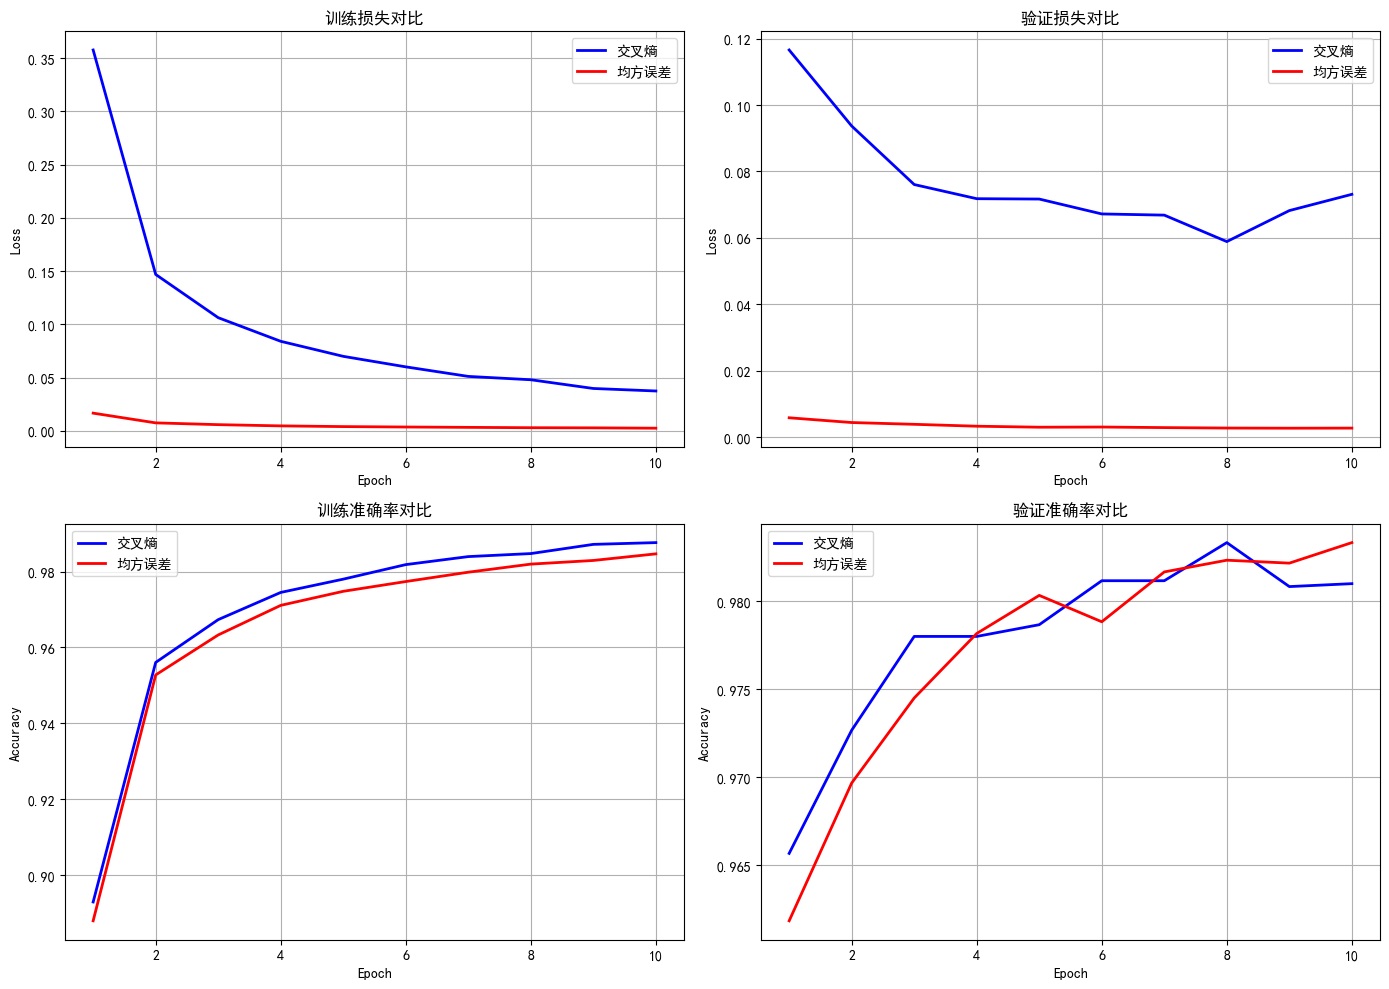


对比图已保存到 task2_loss_comparison.png


In [16]:
# 绘制对比图

# 创建2行2列的子图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 生成epoch编号序列
# range(1, 11)生成1到10的序列
epoch_range = range(1, 11)

# ========== 左上：训练损失对比 ==========

# 'b-'表示蓝色实线
# b = blue（音：布鲁），蓝色
# - = 实线
# linewidth=2（音：莱恩 维斯 吐）- 线宽为2
axes[0, 0].plot(epoch_range, history_ce.history['loss'], 'b-', label='交叉熵', linewidth=2)

# 'r-'表示红色实线
# r = red（音：瑞德），红色
axes[0, 0].plot(epoch_range, history_mse.history['loss'], 'r-', label='均方误差', linewidth=2)

# 设置x轴标签
axes[0, 0].set_xlabel('Epoch')

# 设置y轴标签
axes[0, 0].set_ylabel('Loss')

# 设置标题
axes[0, 0].set_title('训练损失对比')

# 显示图例
axes[0, 0].legend()

# 显示网格
axes[0, 0].grid(True)

# ========== 右上：验证损失对比 ==========
axes[0, 1].plot(epoch_range, history_ce.history['val_loss'], 'b-', label='交叉熵', linewidth=2)
axes[0, 1].plot(epoch_range, history_mse.history['val_loss'], 'r-', label='均方误差', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('验证损失对比')
axes[0, 1].legend()
axes[0, 1].grid(True)

# ========== 左下：训练准确率对比 ==========
axes[1, 0].plot(epoch_range, history_ce.history['accuracy'], 'b-', label='交叉熵', linewidth=2)
axes[1, 0].plot(epoch_range, history_mse.history['accuracy'], 'r-', label='均方误差', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('训练准确率对比')
axes[1, 0].legend()
axes[1, 0].grid(True)

# ========== 右下：验证准确率对比 ==========
axes[1, 1].plot(epoch_range, history_ce.history['val_accuracy'], 'b-', label='交叉熵', linewidth=2)
axes[1, 1].plot(epoch_range, history_mse.history['val_accuracy'], 'r-', label='均方误差', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('验证准确率对比')
axes[1, 1].legend()
axes[1, 1].grid(True)

# 调整布局
plt.tight_layout()

# 保存图片
plt.savefig('task2_loss_comparison.png', dpi=150, bbox_inches='tight')

# 显示图形
plt.show()

# 打印提示
print("\n对比图已保存到 task2_loss_comparison.png")

---

# 实验总结

## 任务一总结

1. **数据预处理**：MNIST数据集包含60000张训练图像和10000张测试图像，每张图像为28x28像素的灰度图。预处理包括：
   - 归一化（Normalization）：将像素值缩放到[0,1]
   - 展平（Flatten）：将2D图像转换为1D向量
   - one-hot编码：将标签转换为10维向量

2. **模型结构**：使用Keras Sequential API构建全连接神经网络：
   - 输入层：784个神经元
   - 隐藏层1：256个神经元 + ReLU激活 + Dropout
   - 隐藏层2：128个神经元 + ReLU激活 + Dropout
   - 输出层：10个神经元 + Softmax激活

3. **训练过程**：使用Adam优化器和交叉熵损失，训练10个epoch

4. **前向传播与反向传播**：
   - 前向传播：数据从输入层逐层计算到输出层
   - 反向传播：用链式法则计算梯度，更新权重

## 任务二总结

1. **交叉熵损失**：专为分类设计，与Softmax配合好，收敛快，准确率高

2. **均方误差损失**：原为回归设计，在分类任务中表现较差

3. **结论**：多分类任务推荐使用交叉熵损失

## 核心概念回顾

| 英文术语 | 音标 | 中文含义 |
|---------|------|---------|
| import | 因剖特 | 导入 |
| neural network | 纽若 奈特沃克 | 神经网络 |
| layer | 莱尔 | 层 |
| activation | 艾克提维逊 | 激活函数 |
| ReLU | 瑞路 | 整流线性单元 |
| Softmax | 索夫特麦克斯 | 归一化指数函数 |
| Dropout | 卓普奥特 | 随机失活 |
| optimizer | 奥普提迈泽 | 优化器 |
| loss | 劳斯 | 损失 |
| gradient | 格雷迪恩特 | 梯度 |
| epoch | 艾波克 | 轮次 |
| batch | 拜奇 | 批次 |
| accuracy | 艾克尤瑞西 | 准确率 |
| forward propagation | 佛沃德 普罗普给逊 | 前向传播 |
| backward propagation | 拜克沃德 普罗普给逊 | 反向传播 |
| overfitting | 欧沃菲挺 | 过拟合 |
| validation | 瓦利戴逊 | 验证 |